# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

## Backtesting Support Level

In the previous notebook, we learned to identify the support and resistance levels. If a level is a support level, that means the price has bounced back from that level at least once. So there is a possibility that when the price retests that level, it might bounce back again. Hence, taking trades on the support/resistance levels can be a good idea.

The strategy will be to find the support levels for a higher timeframe and take a long trade on a shorter timeframe when the close price in the shorter timeframe falls below the support levels. Here, we have taken the higher timeframe as a daily timeframe and the shorter timeframe as a 15-minute timeframe.

In this notebook, we will backtest the above trading strategy.

The notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Resample the Data](#resample)
4. [Get Support Level](#levels)
5. [Entry and Exit Signals](#entry_exit)
6. [Backtesting and Strategy Performance](#backtesting_and_performance)
7. [Conclusion and Next Steps](#conclusion)

<a id='libraries'></a>
## Import Libraries

We will use `price_action_util_quantra`, a custom module that contains functions for getting support level, trade-level analytics and analysis of the strategy's performance.

In [1]:
# For data manipulation
import numpy as np
import pandas as pd

# For visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# For datetime manipulation
from datetime import timedelta

# To ignore warnings
import warnings
warnings.simplefilter('ignore')

# To calculate swing highs and lows
from scipy.signal import argrelextrema

# For backtesting and strategy performance 
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import get_support, trade_level_analytics, get_performance_metrics

<a id='data'></a>
## Read the Data

Import the file `c_minute_2015_2021.csv` using the `read_csv` method of `pandas`. This file has the minute wise OHLCV values for the Citigroup stock. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/c_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the data
data.head()

,Close,High,Low,Open,Volume
2015-01-02 09:30:00+00:00,54.61,54.62,54.35,54.36,819855.0
2015-01-02 09:31:00+00:00,54.58,54.64,54.52,54.59,23892.0
2015-01-02 09:32:00+00:00,54.66,54.69,54.55,54.56,51169.0
2015-01-02 09:33:00+00:00,54.55,54.67,54.54,54.66,46634.0
2015-01-02 09:34:00+00:00,54.47,54.56,54.46,54.54,43558.0


<a id='resample'></a>
## Resample the Data

We will resample the minute data to daily data. To learn more about the resample function, you can refer to the previous notebook and also visit the official documentation page <a href='https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html' target="_blank">here</a>.

In [3]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last',
              'Volume': 'sum'
             }

# Resample the data
data_daily = data.resample('1d', label='left', closed='right').agg(ohlcv_dict).dropna()

# Adjust the index values
data_daily.index += timedelta(hours=16, minutes=00)

# Display the resampled data
data_daily.head()

,Open,High,Low,Close,Volume
2015-01-02 16:00:00+00:00,54.36,54.69,53.79,54.25,9960628.0
2015-01-05 16:00:00+00:00,53.91,53.96,52.33,52.52,17154836.0
2015-01-06 16:00:00+00:00,52.67,52.76,50.53,50.68,30198704.0
2015-01-07 16:00:00+00:00,51.50,51.56,50.62,51.17,24675786.0
2015-01-08 16:00:00+00:00,51.83,52.08,51.50,51.92,15708929.0


<a id='levels'></a>
## Get Support Level

For determining the support level, we will use the price data for the last `90` days, which is stored in the variable `lookback`. You can modify this value as per your logic. 

We will use the `get_support` function from the `price_action_util_quantra` module to get the support level. 

This function takes price and `argrel_window` as inputs and returns the support level. If `argrel_window` is not passed as a parameter, then a value of `15` is taken as the default value. We have discussed this function in detail in the previous notebook.

In [4]:
# Set the lookback period
lookback = 90

# Create and initialise support column with NaN values(for rows where there would be no support)
data_daily['Support'] = np.nan

# Get support level
for i in range(lookback,len(data_daily)):    
    price_data = data_daily.iloc[i-lookback:i]
    
    # Support level
    data_daily.iloc[i, data_daily.columns.get_loc('Support')] =  get_support(price_data)
        
# Display the data
data_daily.head()

,Open,High,Low,Close,Volume,Support
2015-01-02 16:00:00+00:00,54.36,54.69,53.79,54.25,9960628.0,NaN
2015-01-05 16:00:00+00:00,53.91,53.96,52.33,52.52,17154836.0,NaN
2015-01-06 16:00:00+00:00,52.67,52.76,50.53,50.68,30198704.0,NaN
2015-01-07 16:00:00+00:00,51.50,51.56,50.62,51.17,24675786.0,NaN
2015-01-08 16:00:00+00:00,51.83,52.08,51.50,51.92,15708929.0,NaN


<a id='entry_exit'></a>
## Entry and Exit Signals

Our strategy involves determining the support level on daily data and taking trades based on the close price of 15-minute data. Hence we will resample the data to 15-minute data and also merge the daily and 15-minute dataframes to get the support level for trading.

1. Entry: We will enter the trade at the current `Close` price if the previous `Close` price is less than the `Support` price and we have no open positions. This is because if the price has closed below the support level, then there is a chance that it might bounce back.

2. Exit: The trade will be exited if either stop-loss or take-profit gets hit. We have taken the stop-loss and take-profit levels at 10% below and 15% above the entry date's `Close` price, respectively. You can try modifying these levels as per your strategy logic.

In [5]:
# Resample 1-minute data to 15-minute data
data_15 = data.resample('15min', label='right', closed='right').agg(ohlcv_dict).dropna()

# Merge daily and 15-minute data
data_15 = pd.merge(data_15, data_daily['Support'], left_index=True, right_index=True, how='left')

# Forward fill NaN values
data_15 = data_15.fillna(method='ffill')

# Generate entry signal
data_15['signal'] = np.where((data_15.Close < data_15.Support) & (data_15.Close.shift(1) > data_15.Support.shift(1)), 1, 0)

# SL and TP
data_15['SL'] = data_15['Close'] * 0.95
data_15['TP'] = data_15['Close'] * 1.25

# Display the data
data_15.tail()

,Open,High,Low,Close,Volume,Support,signal,SL,TP
2021-02-11 15:00:00+00:00,62.521,62.68,62.517,62.675,332525.0,40.49,0,59.54125,78.34375
2021-02-11 15:15:00+00:00,62.675,62.92,62.645,62.895,423204.0,40.49,0,59.75025,78.61875
2021-02-11 15:30:00+00:00,62.900,62.98,62.855,62.920,401827.0,40.49,0,59.77400,78.65000
2021-02-11 15:45:00+00:00,62.920,63.10,62.910,63.055,674492.0,40.49,0,59.90225,78.81875
2021-02-11 16:00:00+00:00,63.050,63.25,62.990,63.200,1217788.0,40.49,0,60.04000,79.00000


<a id='backtesting_and_performance'></a>
## Backtesting and Strategy Performance

To backtest the strategy, we will follow the same procedure as in previous notebooks with a minor variation. As this strategy runs on 15-minute price data, we will take a long position at the `Close` price of the next 15-minute candle if the `signal` is generated as `1` for the current candle. This is not that significant for the daily data as we can generate the signal a few minutes before the day's `Close` and easily take the trade at the `Close` price of that same day. To accommodate this in our code we will check the `entry_flag` condition first and then the entry conditions so as to append the entry for the next candle after the close is below the support level. Apart from this minor variation, the code for backtesting is the same as that used in the previous notebooks.

For checking the strategy performance, we will use two functions, `trade_level_analytics` for calculating trade-level analytics and `get_performance_metrics` for checking the strategy performance.

In [6]:
# Create dataframes for round trips, storing trades
round_trips_details = pd.DataFrame()
trades = pd.DataFrame()

# Initialise current position, number of trades, cumulative pnl, stop-loss to 0 and take-profit to 100000
current_position = 0
trade_num = 0
cum_pnl = 0
stop_loss = 0
take_profit = 100000

# Set exit flag to False
exit_flag = False
entry_flag = False

for i in data_15.index:
        
    # ------------------------------- Entry Position Update -------------------------------------
    if entry_flag:
        
        
        # Populate the trades dataframe
        trades = pd.DataFrame(index=[0])
        trades['entry_date'] = i
        trades['entry_price'] = data_15.loc[i,'Close']
        trades['position'] = current_position
        
        stop_loss = data_15.loc[i,'SL']

        take_profit = data_15.loc[i,'TP']
        
        # Increase number of trades by 1
        trade_num += 1   
        
        # Print trade details        
        print(f"Trade No: {trade_num} | Entry | Date: {i} | Price: {trades.entry_price[0]} | Position: {current_position}")
        
        # Set exit flag to false
        entry_flag = False

        continue
        
    # ------------------------------- Exit Position Update -------------------------------------        
        
    if exit_flag:
        
        # Populate the trades dataframe
        trades['exit_date'] = i
        trades['exit_type'] = exit_type
        trades['exit_price'] = data_15.loc[i,'Close']
        
        # Add the trade logs to round trip details
        round_trips_details = pd.concat([round_trips_details,trades])
        
        # Calculate pnl for the trade
        trade_pnl = round(trades.exit_price[0] - trades.entry_price[0],1)
        
        # Calculate cumulative pnl
        cum_pnl += trade_pnl
        cum_pnl = round(cum_pnl,1)
        trades['PnL'] = trade_pnl
        
        # Add the trade logs to round trip details
        round_trips_details = pd.concat([round_trips_details, trades])

        # Print trade details
        print(f"Trade No: {trade_num} | Exit Type: {exit_type} | Date: {i} | Exit Price: {trades.exit_price[0]} | PnL: {trade_pnl} | Cum PnL: {cum_pnl}")                              
        print("-"*30)
        
        # Update current position to 0
        current_position = 0    

        # Set exit flag to false
        exit_flag = False          
        
        continue
        
        
    if (current_position == 0) & (data_15.loc[i, 'signal'] == 1):        
        current_position = data_15.loc[i, 'signal']
        entry_flag = True
            
            
    elif current_position == 1:
        if data_15.loc[i,'Close'] < stop_loss:
            exit_type = 'SL'            
            exit_flag = True  

        elif data_15.loc[i,'Close'] > take_profit:
            exit_type = 'TP'            
            exit_flag = True              

Trade No: 1 | Entry | Date: 2015-08-24 09:45:00+00:00 | Price: 51.1 | Position: 1
Trade No: 1 | Exit Type: SL | Date: 2015-09-29 10:00:00+00:00 | Exit Price: 48.97 | PnL: -2.1 | Cum PnL: -2.1
------------------------------
Trade No: 2 | Entry | Date: 2016-01-07 15:45:00+00:00 | Price: 47.87 | Position: 1
Trade No: 2 | Exit Type: SL | Date: 2016-01-13 14:15:00+00:00 | Exit Price: 45.5 | PnL: -2.4 | Cum PnL: -4.5
------------------------------
Trade No: 3 | Entry | Date: 2016-06-14 10:45:00+00:00 | Price: 42.56 | Position: 1
Trade No: 3 | Exit Type: SL | Date: 2016-06-24 09:45:00+00:00 | Exit Price: 40.94 | PnL: -1.6 | Cum PnL: -6.1
------------------------------
Trade No: 4 | Entry | Date: 2016-06-27 09:30:00+00:00 | Price: 39.33 | Position: 1
Trade No: 4 | Exit Type: TP | Date: 2016-10-07 11:30:00+00:00 | Exit Price: 49.09 | PnL: 9.8 | Cum PnL: 3.7
------------------------------
Trade No: 5 | Entry | Date: 2018-03-22 15:30:00+00:00 | Price: 70.57 | Position: 1
Trade No: 5 | Exit Type: 

In [7]:
round_trips_details.index = range(0, len(round_trips_details))
data_15.signal = 0

# Iterate over each row in the 'trades' DataFrame
for index, trade in round_trips_details.iterrows():
    # Extract the entry date of the trade
    entry_time = round_trips_details['entry_date'][index]
    
    # Extract the exit date of the trade
    exit_time = round_trips_details['exit_date'][index]
    
    # Extract the position of the trade (e.g., -1 for short)
    position = round_trips_details['position'][index]
    
    # Update the 'signal' column in the 'data' DataFrame for the date range
    # between the entry date and the exit date with the corresponding position
    data_15.loc[entry_time:exit_time, 'signal'] = position

In [8]:
# Trade Level Analytics
analytics = trade_level_analytics(round_trips_details)
analytics

,Strategy
Total PnL,6.9
total_trades,26
Number of Winners,3
Number of Losers,10
Win (%),11.538462
Loss (%),38.461538
per_trade_PnL_winners,12.233333
per_trade_PnL_losers,2.98
Average holding time,43 days 00:34:36.923076923
Profit Factor,1.231544


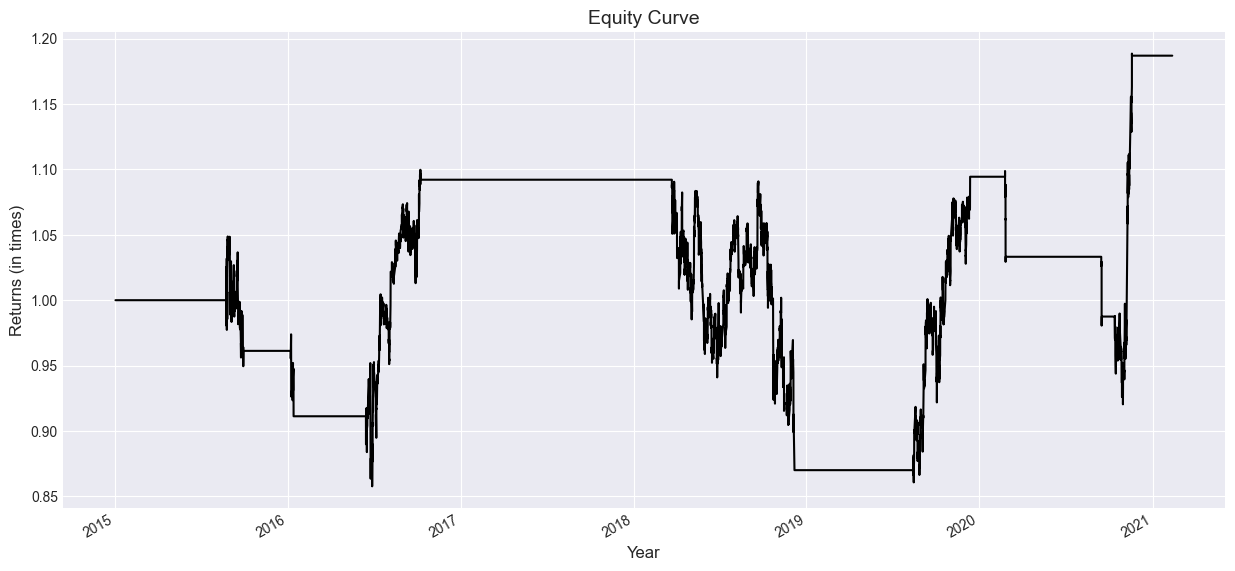

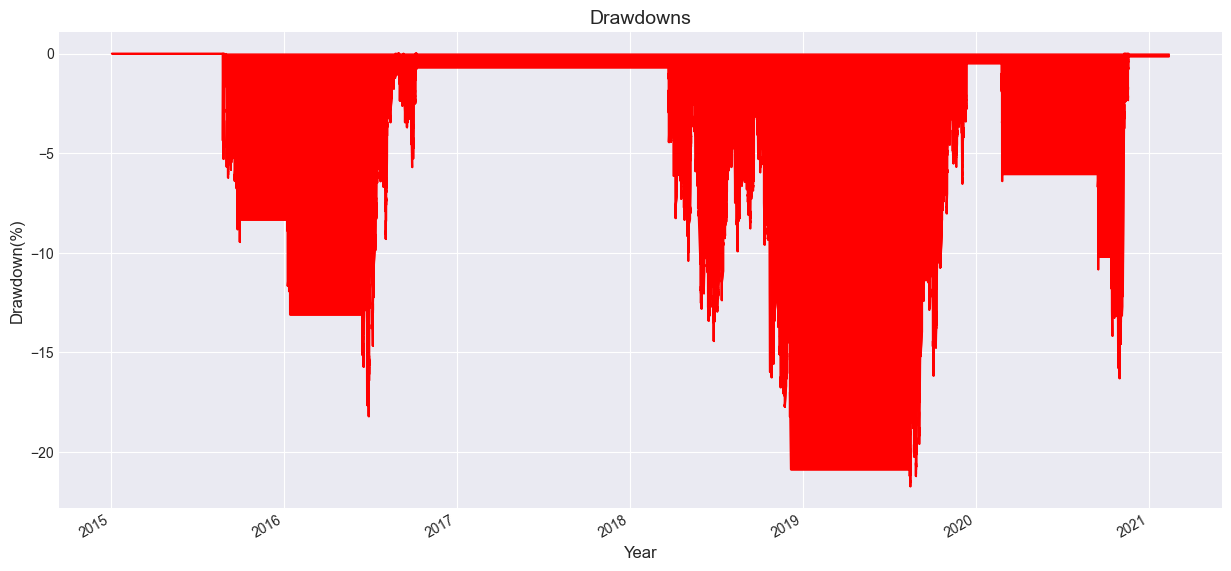

                 Strategy
CAGR                2.88%
Sharpe Ratio         0.13
Maximum Drawdown  -21.73%


In [9]:
# Performance metrics
performance_metrics = get_performance_metrics(data_15)

<a id='conclusion'></a>
## Conclusion and Next Steps

In this notebook, you understood how to set the risk management parameters and backtest a complete strategy based on the support  level. We also analysed the performance of our trading strategy to get a deeper idea about the strategy performance. You can now try to backtest a trading strategy on support and resistance levels for different parameters.<br><br>